In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import numpy as np

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# 70000 images in MNIST dataset

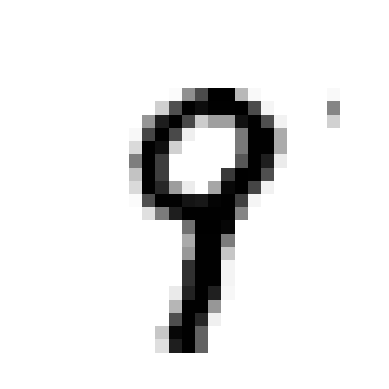

In [7]:
some_digit=x_train[227]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap="binary")
plt.axis("off")
plt.show()

In [9]:
y_train[227]

np.uint8(9)

In [10]:
print("Size of the dataset:", len(x_train) + len(x_test))
print("Number of elements in the training set:", len(x_train))
print("Number of elements in the test set:", len(x_test))

Size of the dataset: 70000
Number of elements in the training set: 60000
Number of elements in the test set: 10000


In [36]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

Test accuracy: 0.9705


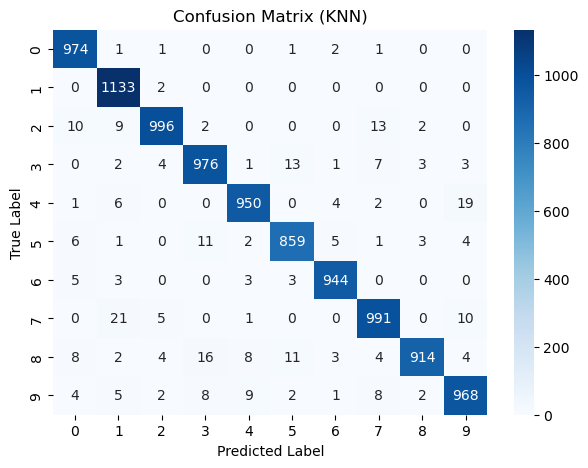

In [37]:
# ================== KNN ORIGINAL ==================
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
accuracy = knn.score(x_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (KNN)")
plt.show()

Tuned Test accuracy: 0.9691


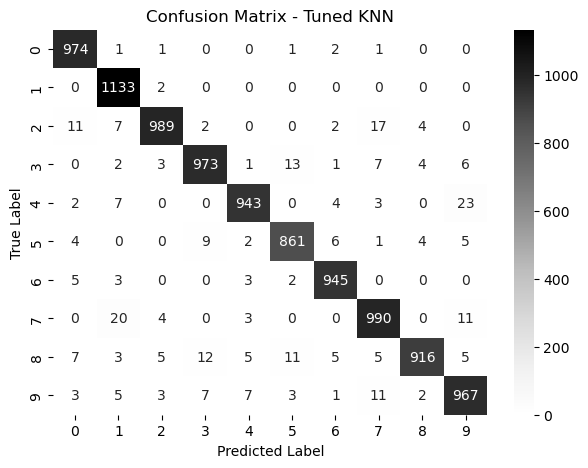

In [19]:
# ================== KNN TUNED ==================
# Changed 2 hyperparameters:
# 1) n_neighbors: 3 → 5
# 2) weights: default('uniform') → 'distance'
knn_tuned = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_tuned.fit(x_train, y_train)
y_pred = knn_tuned.predict(x_test)
accuracy = knn_tuned.score(x_test, y_test)
print(f"Tuned Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned KNN")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

Logistic Regression Test Accuracy: 0.9219


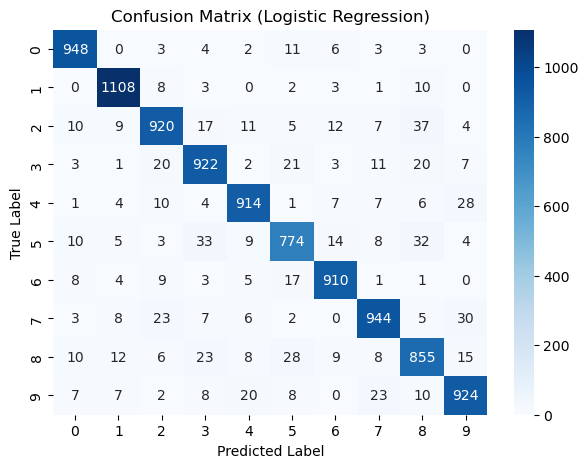

In [28]:
# ================== LOGISTIC ORIGINAL ==================
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

logreg = LogisticRegression(C=1.0, max_iter=1000)
logreg.fit(x_train_scaled, y_train)

y_pred_logreg = logreg.predict(x_test_scaled)
accuracy = logreg.score(x_test_scaled, y_test)
print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

Tuned Logistic Regression Test Accuracy: 0.9273


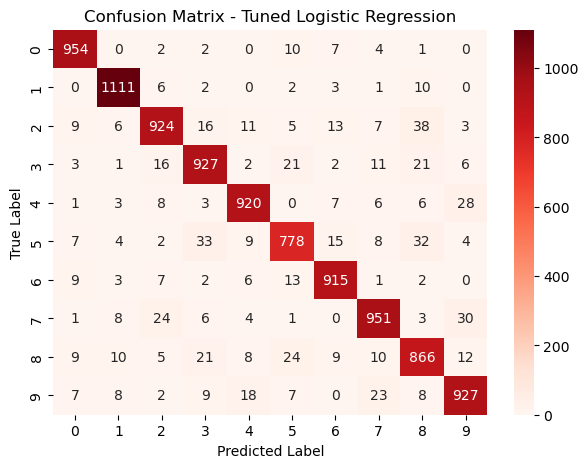

In [30]:
# ================== LOGISTIC TUNED ==================
# Changed 2 hyperparameters:
# 1) max_iter: 1000 → 2000
# 2) C(the inverse of regularization strength): 1.0 → 0.1

logreg_tuned = LogisticRegression(C=0.1, max_iter=2000)
logreg_tuned.fit(x_train_scaled, y_train)

y_pred_logreg = logreg_tuned.predict(x_test_scaled)
accuracy = logreg_tuned.score(x_test_scaled, y_test)
print(f"Tuned Logistic Regression Test Accuracy: {accuracy:.4f}")

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

Test accuracy: 0.8780


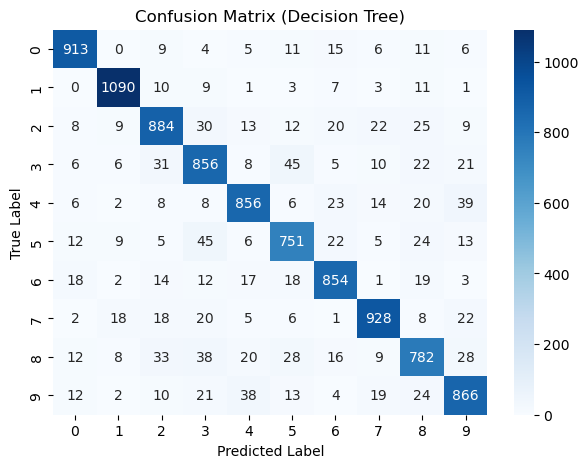

In [33]:
# ================== DECISION TREE ORIGINAL ==================
# Default:
# 1) criterion: "gini"
# 2) max_depth: None (no limit)
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(x_train, y_train)
y_pred = dt_classifier.predict(x_test)
accuracy = dt_classifier.score(x_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()


Tuned Test accuracy: 0.8831


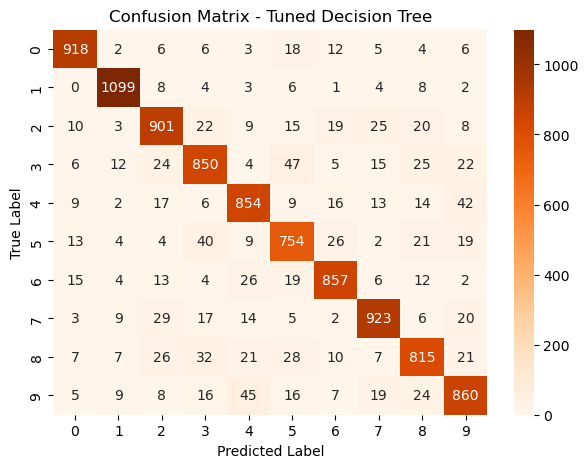

In [35]:
# ================== DECISION TREE TUNED ==================
# Changed 2 hyperparameters:
# 1) max_depth: None → 20
# 2) criterion: default('gini') → 'entropy'
dt_classifier_tuned = DecisionTreeClassifier(max_depth=20, criterion='entropy')
dt_classifier_tuned.fit(x_train, y_train)
y_pred = dt_classifier_tuned.predict(x_test)
accuracy = dt_classifier_tuned.score(x_test, y_test)
print(f"Tuned Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()